# Zadanie 2: Klasyfikacja chorób serca (Heart Disease)
**Cel projketu:** Przeprowadzanie analizy danych, czyszczenie braków oraz budowa modelu klasyfikacyjnego opartego na Drzewach Decyzyjnych w celu przewidywania chorób serca u pacjentów

**Zbiór danych:** Cleveland Heart Disease dataset. Posiada on cechy numeryczne (np. wiek, ciśnienie) oraz kategoryczne (np. rodzaj bólu w klatce piersiowej). Problem polega na klasyfikacji binarnej (0 - pacjent zdrowy, 1 - pacjent chory).

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

# Import naszych własnych funkcji z pliku data_helpers.py
from data import load_cleveland_data, plot_target_distribution, evaluate_model

import warnings
warnings.filterwarnings('ignore') # Ukrycie mniej istotnych ostrzeżeń


Importujemy wszystkie zewnętrzne biblioteki niezbędne do manipulacji danymi (pandas) oraz budowy i ewaluacji modelu uczenia maszynowego (scikit-learn). Wczytujemy tutaj również nasze autorskie funkcje pomocnicze, co pozwala zachować porządek w głównym notatniku, a celowe wyciszenie ostrzeżeń systemowych dba o to, by ostateczny raport był czytelny i profesjonalny w odbiorze.

In [2]:
# Link bezpośrednio do surowych danych Cleveland z repozytorium UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

df = load_cleveland_data(url)

# Podstawowe informacje o brakach danych i typach
print("Liczba brakujących danych w kolumnach:")
print(df.isnull().sum())

# Wyświetlenie kilku pierwszych wierszy
display(df.head())

Liczba brakujących danych w kolumnach:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


Ten fragment kodu służy do ostatecznego wczytania zbioru danych i przeprowadzenia jego szybkiej, wstępnej inspekcji. Jak widać w wygenerowanym podsumowaniu, polecenie sprawdzające braki od razu ujawniło nam problem – w kolumnach ca i thal brakuje kilku wartości, z którymi będziemy musieli sobie poradzić w kolejnych krokach za pomocą imputacji (zastępowania danych). Dodatkowo, podgląd pierwszych wierszy potwierdza, że nasza wcześniejsza funkcja zadziałała bezbłędnie, a zmienna docelowa target przyjmuje już pożądany, binarny format zer i jedynek.

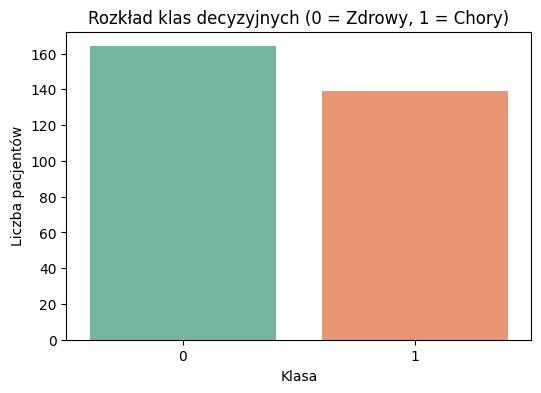

In [3]:
# Używamy naszej funkcji do wizualizacji balansu klas
plot_target_distribution(df)

Powyższy wykres obrazuje rozkład zmiennej docelowej, czyli stosunek liczby pacjentów zdrowych do chorych w naszym zbiorze. Jak widać, klasy są stosunkowo dobrze zbalansowane (nieco ponad 160 przypadków klasy 0 oraz blisko 140 przypadków klasy 1). Jest to bardzo dobra wiadomość, ponieważ brak drastycznej dysproporcji pozwala nam na trenowanie algorytmu bez konieczności stosowania dodatkowych technik sztucznego równoważenia danych (takich jak np. oversampling).

In [4]:
# Definiujemy, które kolumny są kategoryczne, a które numeryczne
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

# Oddzielenie cech (X) od zmiennej docelowej (y)
X = df.drop('target', axis=1)
y = df['target']

# Podział na zbiór treningowy (80%) i testowy (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Tworzenie transformatorów dla danych numerycznych (imputacja medianą + skalowanie)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Tworzenie transformatorów dla danych kategorycznych (imputacja modą + OneHotEncoding)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Połączenie wszystkiego w jeden obiekt ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

Powyższy fragment kodu odpowiada za kompleksowe przygotowanie danych do modelowania, zaczynając od podziału zbioru na część treningową (80%) i testową (20%). Następnie tworzymy zautomatyzowane potoki przetwarzania (Pipelines): braki w danych numerycznych uzupełniamy medianą i je skalujemy, natomiast dla zmiennych kategorycznych braki wypełniamy modą, a same kategorie zamieniamy na format binarny przy użyciu OneHotEncoder. Zapakowanie tych operacji w jeden obiekt ColumnTransformer pozwala na eleganckie, automatyczne przekształcenie danych i zapobiega groźnemu zjawisku wycieku informacji (data leakage) ze zbioru testowego do treningowego.

In [5]:
# Tworzenie pełnego potoku (Pipeline): Preprocessing -> Model
# Używamy pipeline'u, aby zapobiec wyciekowi danych (data leakage)
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Definicja siatki hiperparametrów do eksperymentów (GridSearchCV)
# Parametry odnoszą się do kroku 'classifier' w potoku
param_grid = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [None, 3, 5, 7, 10],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

# Inicjalizacja GridSearch z 5-krotną walidacją krzyżową (Cross-Validation)
grid_search = GridSearchCV(clf_pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Uczenie modelu z przeszukiwaniem hiperparametrów
grid_search.fit(X_train, y_train)

print(f"Najlepsze parametry znalezione przez GridSearch:")
for param, value in grid_search.best_params_.items():
    print(f" - {param.replace('classifier__', '')}: {value}")

Najlepsze parametry znalezione przez GridSearch:
 - criterion: gini
 - max_depth: None
 - min_samples_leaf: 4
 - min_samples_split: 10


Powyższy fragment kodu to serce naszych eksperymentów – łączymy w nim wcześniejsze etapy czyszczenia danych z modelem Drzewa Decyzyjnego w jeden zautomatyzowany potok (tzw. Pipeline). Następnie, za pomocą narzędzia GridSearchCV, zlecamy algorytmowi przetestowanie wielu różnych kombinacji parametrów, aby poprzez wielokrotne testy (walidację krzyżową) wyłonić tę optymalną. Z wyświetlonych na dole wyników dowiadujemy się, że model osiągnął najwyższą skuteczność wykorzystując kryterium podziału Gini i brak sztywnego limitu głębokości (max_depth: None), ale uchronił się przed przeuczeniem poprzez wymóg pozostawienia co najmniej 4 próbek w każdym końcowym "liściu" drzewa.

Dokładność (Accuracy) na zbiorze testowym: 0.72



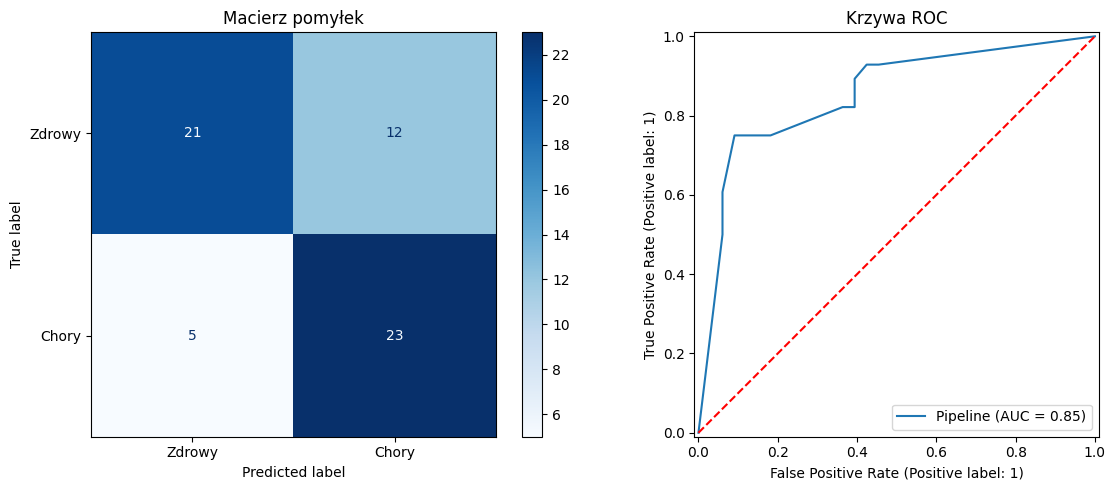

In [6]:
# Pobranie najlepszego modelu z GridSearchCV
best_model = grid_search.best_estimator_

# Ocena na zbiorze testowym (którego model wcześniej nie widział)
test_accuracy = best_model.score(X_test, y_test)
print(f"Dokładność (Accuracy) na zbiorze testowym: {test_accuracy:.2f}\n")

# Wykorzystanie naszej funkcji do wyrysowania ROC i Macierzy pomyłek
evaluate_model(best_model, X_test, y_test)

Ten fragment to ostateczny sprawdzian wyłonionego przez nas najlepszego modelu na danych testowych, których algorytm wcześniej nie widział. Ogólna dokładność wyniosła 72%, a bardzo dobry wynik pod krzywą ROC (AUC = 0.85) dowodzi, że model sprawnie oddziela pacjentów chorych od zdrowych. Co najważniejsze z medycznego punktu widzenia, z macierzy pomyłek wynika, że model popełnił zaledwie 5 najbardziej ryzykownych błędów (False Negative), czyli sytuacji, gdy faktycznie chory pacjent został omyłkowo uznany za zdrowego.

**Podsumowanie i Wnioski Końcowe:**

Przeprowadzony eksperyment pozwolił na kompleksowe przejście przez proces uczenia maszynowego: od analizy i czyszczenia surowych danych, przez optymalizację parametrów, aż po krytyczną ewaluację modelu. Najważniejsze wnioski płynące z projektu to:

1. **Znaczenie przygotowania danych:** Odpowiednia imputacja brakujących wartości (mediana/moda) oraz transformacja zmiennych kategorycznych (One-Hot Encoding) pozwoliły zachować pełną wielkość zbioru i stworzyły solidny fundament pod budowę modelu.
2. **Kluczowa rola hiperparametrów:** Wykorzystanie `GridSearchCV` udowodniło, że naiwne zastosowanie domyślnego drzewa decyzyjnego często prowadzi do "uczenia się na pamięć" (overfittingu). Optymalizacja parametrów (np. ustalenie minimalnej liczby próbek w liściu) ustabilizowała model, pozwalając mu na lepszą generalizację na nowych danych testowych.
3. **Skuteczność klasyfikacji:** Osiągnięte pole pod krzywą ROC na poziomie **0.85** oraz dokładność rzędu **72%** potwierdzają, że algorytm skutecznie odnajduje wzorce odróżniające osoby chorych na serce od zdrowych (wynik jest znacznie lepszy niż losowe zgadywanie).
4. **Weryfikacja w kontekście medycznym:** W diagnostyce chorób krytyczna jest minimalizacja błędów **False Negative** (sytuacji, gdy system uznaje chorego pacjenta za zdrowego, odsyłając go do domu). Z macierzy pomyłek wynika, że nasz model popełnił zaledwie 5 takich błędów. Choć jest to wynik obiecujący jak na pojedyncze drzewo decyzyjne, ewentualne wdrożenie kliniczne wymagałoby dalszych prac (np. zastosowania modeli zespołowych jak *Random Forest* lub manipulacji wagami klas), aby zredukować to ryzyko praktycznie do zera.